In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Aprendizaje Supervisado
# Regresión Lineal Simple
Autor: Mgtr. Ing. Mariano Martín Gualpa


En este documento, revisaremos algunos conceptos relacionados con los modelos de regresión lineal.

Vamos a trabajar con algunos números aleatorios, además de que algunos algoritmos utilizan números aleatorios, por ello es necesario establecer una semilla para facilitar la reproducibilidad.

In [2]:
np.random.seed(20)

# 1. Generación del Conjunto de Datos Sintético

Generaremos una distribución artificial para hacer algunas pruebas.
Por ello, generaremos un conjunto X con sus correspondientes Y, asociados por una función subyacente que las relaciona. Agregaremos un poco de ruido aleatorio para asemejarlo un poco a las condiciones normales en que podríamos encontrar la información de un data set real.


In [3]:
n_samples = 20

Primero generamos un conjunto de valores aleatorio para x, con una distribución uniforme dentro del espacio [0, 50].

In [4]:
x = np.random.uniform(0, 50, n_samples)
print(x)

[29.40654005 44.8856864  44.57653647 40.79187387  1.79447928 34.58787909
 18.9340471  25.92554727 32.89757328  9.69251089 13.6158201  35.93029668
 39.15018047 42.51638199 38.7622447   1.83321532  5.83468676 37.56403497
 11.96091081 12.7403007 ]


Establecemos los parámetros de la función subyacente. Se trata de una función lineal simple: y = a x + b <br>
Sobre ella, agregaremos un poco de ruido guassiano. Los parámetros de la función serán:

In [5]:
a = 10
b = 0.5
mu = 0
sigma = 4


A partir de estos parámetros, generamos los valores correspondientes de la variable y asociados a cada elemento de x:

In [6]:
y = a + b * x + np.random.normal(mu, sigma, size=len(x))
print(y)

[19.58525938 33.42570388 32.11148903 36.66646714 15.10167436 28.91941325
 18.79243915 10.20396248 30.92931568 20.17736828 15.83455499 27.44502549
 29.13902075 37.48293675 29.89623576  2.64881277  9.37537076 24.36369955
 19.71192079 24.60950235]


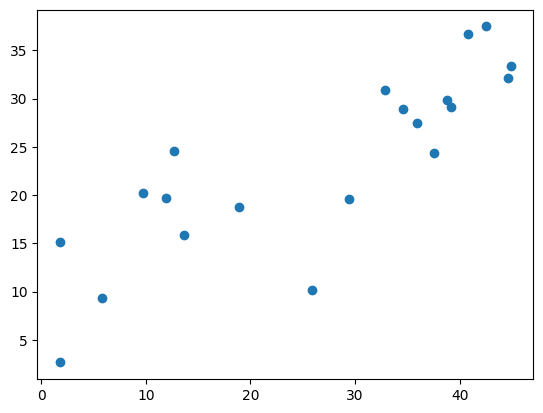

In [7]:
plt.plot(x, y, 'o');

Hemos generado así un dataset artificial, que nos servirá para poder entender mejor los conceptos relacionados a esta unidad. Podríamos suponer que este conjunto de datos representa a dos variables cuya relación desconocemos y de la que solo tenemos los valores disponibles.

# 2. Generar el Modelo Lineal a partir de una Regresión Lineal Simple
El objetivo es encontrar a partir de los datos, una función h(x) que permita estimar el valor correspondiente de y. Existen muchos modelos que pueden ayudarnos, en este caso utilizaremos un modelo lineal: $$ \widehat{y} = w_0 + w_1 * x$$

En sklearn, disponemos de la clase `LinearRegression` (referencia a la [*API*](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)), que implementa un tipo de regresión llamada Ordinary Least Squares (OLS).



## 2.1. Preparación del dataset.

Para realizar el entrenamiento, la API de sklearn requiere normalmente dos parámetros:

el conjunto de valores de la variable objetivo ($\mathbf{y}$) en la forma de un array de 1 dimensión.
el conjunto de valores de las variables Xi, en la forma de un array de dos dimensiones es decir una matriz ($X$).

Cada fila de ($X$) corresponde a un ejemplo y tendrá asociado un elemento correspondiente en el vector($\mathbf{y}$). Cada columna, corresponderá a una variable, característica o feature.


In [8]:
x.shape

(20,)

Puede observarse que ($\mathbf{x}$) es un array de una dimensión (vector), por lo que deberíamos realizar la conversión a un array bi-dimensional (matriz), que en este caso tendrá una única columna y una fila por cada ejemplo.

In [9]:
X = x[:, np.newaxis]
X.shape

(20, 1)

## 2.2. Separación en conjunto de entrenamiento y test.
Una práctica normal en la búsqueda del $h(x)$ mas adecuado es la de dividir el conjunto en al menos dos partes que serán utilizadas para objetivos diferentes:
- Una parte será utilizada para ajustar el modelo (entrenamiento o train).
- Otra parte diferente será utilizada para medir que tan bueno es el modelo obtenido (validación o test).
Posteriormente volveremos sobre este concepto y profundizaremos sobre por que es tan importante.

Por lo pronto, dividiremos el conjunto de datos en 80% y 20%. Para ello, utilizaremos la función `sklearn.model_selection`.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=311)

## 2.3. Ajuste del Modelo (Entrenamiento)
Utilizaremos la clase `LinearRegression` de sklearn con **los datos de entrenamiento**  para ajustar los parametros del modelo:

In [11]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

El objeto `regressor` contiene el modelo ya entrenado. Como el modelo es lineal, sus parámetros son: $$ \widehat{y} = w_0 + w_1 x$$

In [12]:
print('Vector de coeficientes de la función lineal: ', regressor.coef_)
print('Ordenada en el origen (W0): ', regressor.intercept_)

Vector de coeficientes de la función lineal:  [0.42976778]
Ordenada en el origen (W0):  12.102110205104022


Vamos a graficar la función obtenida, junto con los puntos de entrenamiento:

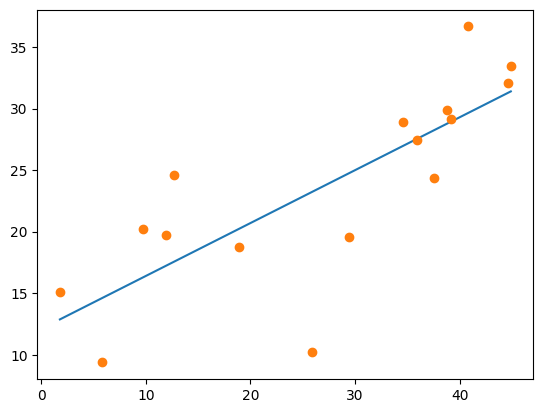

In [13]:
xlin = np.linspace(X.min(), X.max(), 200)
ylin = regressor.coef_[0] * xlin + regressor.intercept_

plt.plot(xlin, ylin)
plt.plot(X_train, y_train, 'o');

Podemos calcular la predicción para cada valor de $x$ de entrenamiento.

In [14]:
y_pred_train = regressor.predict(X_train)

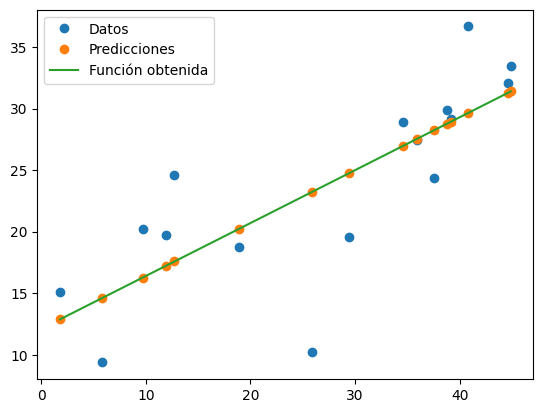

In [15]:
plt.plot(X_train, y_train, 'o', label="Datos")
plt.plot(X_train, y_pred_train, 'o', label="Predicciones")
plt.plot(xlin, ylin, label='Función obtenida')
plt.legend(loc='best')

## 2.4. Evaluación de Desempeño del Modelo

### 2.4.1. Gráfico Q-Q (QQ-Plot)



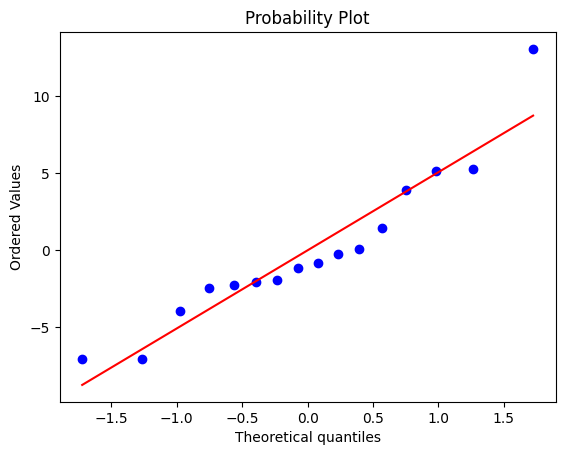

In [16]:
from scipy.stats import probplot

residuals = y_pred_train - y_train
_ = probplot(residuals, plot=plt)

### 2.4.2. Gráfico de Residuos

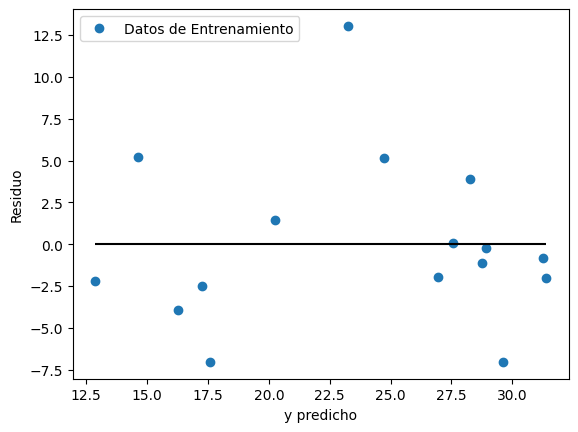

In [17]:
plt.plot(y_pred_train, residuals, 'o', label="Datos de Entrenamiento")
plt.hlines(y = 0, xmin = min(y_pred_train), xmax = max(y_pred_train), color = 'black')
plt.xlabel('y predicho')
plt.ylabel('Residuo')
plt.legend(loc='best')

In [19]:
y_pred_test = regressor.predict(X_test)

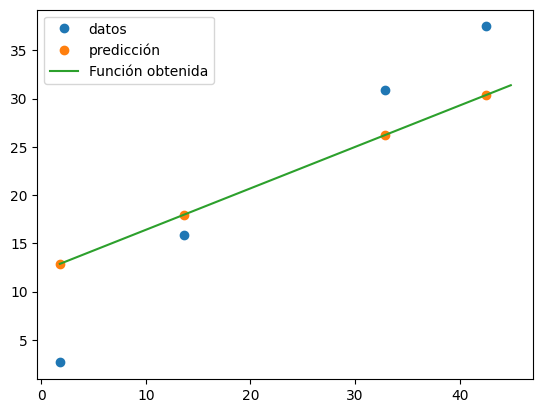

In [20]:
plt.plot(X_test, y_test, 'o', label="datos")
plt.plot(X_test, y_pred_test, 'o', label="predicción")
plt.plot(xlin, ylin, label='Función obtenida')
plt.legend(loc='best');

### 2.4.3. Métricas

Existen diferentes métricas para evaluar el desempeño del modelo y las estimaciones que pueden obtenerse.
En regresión, las dos principales son el coeficiente de determinación $R^2$ y el Error Cuadrático Medio (Mean Squared Error MSE).
- Error Cuadrático Medio (MSE):
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (\widehat{y}^{(i)} - \text{y}^{(i)})^2$$
- Coeficiente de Determinación ($R^2$):
$$R^2 = 1 - \frac{SSE}{SST} = 1 - \frac{\frac{1}{n} \sum_{i=1}^{n} (\widehat{y}^{(i)} - \text{y}^{(i)})^2}{\frac{1}{n} \sum_{i=1}^{n} (\text{y}^{(i)} - \mu_y)^2} = 1 - \frac{MSE}{Var(y)}$$

SSE: Sum of squared errors

SST: Total sum of squared.


In [21]:
regressor.score(X_test, y_test)

0.7513895951359573

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

print('Error Cuadrático Medio (Mean Squared Error): %.8f' % mean_squared_error(y_test, y_pred_test))
print('Coeficiente de Determinación (Coefficient of Determination): %.8f' % r2_score(y_test, y_pred_test))

Error Cuadrático Medio (Mean Squared Error): 45.47272345
Coeficiente de Determinación (Coefficient of Determination): 0.75138960


<div class="alert alert-warning">
    <b>Actividad</b>:
    <hr>
     <ul>
      <li>Comparar los parámetros del modelo subyacente con los del modelo obtenido.</li>
      <li>Aumentar la cantidad de muestras y ejecutar nuevamente toda la notebook.</li>
    <li>Revisar cambios en los resultados.</li>
    </ul>
</div>